In [1]:
# =============================================================================
#  STOCK WEEKLY TREND CLASSIFICATION  [v4.0 — Adaptive Kalman Filter]
#
#  KIẾN TRÚC:
#    Raw Close Price
#    ↓
#    Adaptive Kalman Filter  [state: price, velocity, acceleration]
#    ↓
#    kf_price  (denoised close)
#    ↓
#    Feature Engineering  (tất cả indicators tính trên kf_price)
#    ↓
#    Base Features
#
#  KALMAN STATE / UNCERTAINTY FEATURES:
#    kf_price, kf_velocity, kf_acceleration
#    kf_residual, kf_residual_abs
#    noise_ratio, signal_to_noise
#    uncertainty_ratio, kalman_gain, kf_return
#    → P2 Ensemble Features  +  P4 Stream-B Features
#
#  PIPELINE v4.0:
#    P1: LightGBM + RF  (base features, không scale)
#    P2: LightGBM + RF  (base + Kalman state/uncertainty features, không scale)
#    P3: BiLSTM + Attention  (scaled base features only)
#    P4: DualStream BiLSTM + CrossAttention  (Stream B = Kalman state features)
#
#  LÝ DO THIẾT KẾ:
#    - Constant-acceleration kinematic model captures short-term price momentum.
#      State vector [price, velocity, acceleration] allows the filter to track
#      trending markets more smoothly than scalar F=1, and directly generates
#      velocity and acceleration as interpretable state variables for Stream B.
#    - Adaptive noise estimation tự hiệu chỉnh Q/R theo từng fold walk-forward.
#    - Stream B của P4 chỉ nhận Kalman scalar features (không nhận raw latents)
#      để tránh gradient conflict với Stream A.
# =============================================================================

In [2]:
import warnings, os, random, gc
warnings.filterwarnings('ignore')
os.environ['CUDA_VISIBLE_DEVICES']      = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL']      = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
from tensorflow.keras import layers, Model, Input, callbacks, optimizers, regularizers
from tensorflow.keras.utils import to_categorical

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 9,
})

E0000 00:00:1780233616.939554      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780233617.001790      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780233617.541472      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780233617.541514      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780233617.541518      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780233617.541521      16 computation_placer.cc:177] computation placer already registered. Please check linka

In [3]:
# =============================================================================
# CONFIG
# =============================================================================
DATA_PATH_FPT = "/kaggle/input/datasets/cdnghnam/fptckhon/FPT raw.csv"
DATA_PATH_CMC = "/kaggle/input/datasets/cdnghnam/cmcckhon/CMC raw.csv"

SIGNAL_THR = 2.0
CLASSES    = ['up', 'down']

# Walk-forward
INIT_FRAC     = 0.75
MIN_FOLD_SIZE = 20      # tối thiểu 20 tuần/fold để model học được
MAX_FOLDS     = 5

# ── Adaptive Kalman Filter ────────────────────────────────────────────────────
# State vector: [price, velocity, acceleration]
KF_Q_SCALE   = 1e-4    # process noise scale (Q); adaptive estimation sẽ refine
KF_R_SCALE   = 1e-2    # measurement noise scale (R)
KF_ADAPTIVE  = True    # bật adaptive Q/R estimation theo innovation sequence
KF_FINETUNE  = True   # fine-tune lại filter params mỗi fold (nếu True)

# Stream B của P4: 4 Kalman scalar features for CrossAttention context
# (velocity + acceleration capture momentum; gain + uncertainty capture filter confidence)
KF_STREAM_B_COLS = [
    'kf_velocity', 'kf_acceleration', 'kalman_gain', 'uncertainty_ratio'
]

# ── LSTM Classifier ───────────────────────────────────────────────────────────
SEQ_LEN      = 12
LSTM_UNITS_A = 48
LSTM_UNITS_B = 16   # narrow — stream B chỉ có Kalman scalar features
LSTM_DROPOUT = 0.30
LSTM_EPOCHS  = 80
LSTM_BATCH   = 16
LSTM_LR      = 5e-4

OUT_DIR = '/kaggle/working'
os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 72)
print("  Weekly Trend Classification  [v4.0 — Adaptive Kalman + CrossAttn DualStream]")
print(f"  Signal thr={SIGNAL_THR}%  |  Stream B: {KF_STREAM_B_COLS}")
print("=" * 72)

  Weekly Trend Classification  [v4.0 — Adaptive Kalman + CrossAttn DualStream]
  Signal thr=2.0%  |  Stream B: ['kf_velocity', 'kf_acceleration', 'kalman_gain', 'uncertainty_ratio']


In [4]:
# =============================================================================
# PART 1 — LOAD
# =============================================================================

def load_daily(path, high_col, low_col, vol_col, close_col, date_col='Date'):
    df = pd.read_csv(path, parse_dates=[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df[df.columns[1:]] = df[df.columns[1:]].ffill().bfill()
    return pd.DataFrame({
        'date'  : df[date_col],
        'close' : df[close_col].astype(float),
        'high'  : df[high_col].astype(float),
        'low'   : df[low_col].astype(float),
        'volume': df[vol_col].astype(float),
    })

In [5]:
# =============================================================================
# PART 2 — LABEL
# =============================================================================

def label_weekly(df_w, signal_thr=SIGNAL_THR):
    df = df_w.copy()
    df['weekly_ret'] = df['close'].pct_change() * 100
    df['next_ret']   = df['weekly_ret'].shift(-1)
    df['next_close'] = df['close'].shift(-1)
    df['label'] = np.where(df['next_ret'] >  signal_thr, 'up',
                  np.where(df['next_ret'] < -signal_thr, 'down', 'sideways'))
    df = df[df['label'] != 'sideways'].dropna(subset=['next_ret', 'label'])
    df = df.reset_index(drop=True)
    print(f"  After dropping sideways: {len(df)} weeks")
    vc = df['label'].value_counts()
    print(f"  up={vc.get('up',0)}  down={vc.get('down',0)}  "
          f"(up rate={vc.get('up',0)/len(df)*100:.1f}%)")
    return df

In [6]:
# =============================================================================
# PART 3 — FEATURES
# =============================================================================

def build_weekly_features(df_w, kf_price=None):
    """
    Build technical indicator features.

    Parameters
    ----------
    df_w      : DataFrame — labeled weekly OHLCV data (from label_weekly)
    kf_price  : 1-D array-like, optional
        Kalman-denoised close price aligned with df_w rows.
        When provided, ALL close-derived indicators are computed from
        kf_price instead of raw close.  Labels, high, low, volume,
        streaks, and calendar features are unaffected.
        If None, falls back to raw close (backward-compatible).

    Returns
    -------
    (feature_DataFrame, label_Series)
    """
    f = df_w.copy().reset_index(drop=True)

    # ── Primary price source ──────────────────────────────────────────────────
    # kf_price replaces raw close for ALL indicator computation.
    # We inject it as a temporary column so .shift(1) works uniformly.
    if kf_price is not None:
        kp = np.asarray(kf_price, dtype=np.float64)
        assert len(kp) == len(f), (
            f"kf_price length {len(kp)} != df_w length {len(f)}")
        f['_kf_close'] = kp
        c = f['_kf_close'].shift(1)   # lagged denoised price (leak-free)
    else:
        c = f['close'].shift(1)       # original behaviour

    h = f['high'].shift(1)
    l = f['low'].shift(1)
    v = f['volume'].shift(1)
    r = f['weekly_ret'].shift(1)

    # ── Returns ───────────────────────────────────────────────────────────────
    for w in [1, 2, 3, 4, 8, 13, 26]:
        f[f'ret_{w}w'] = c.pct_change(w) * 100

    # ── Momentum / Moving Averages ────────────────────────────────────────────
    for w in [4, 8, 13, 26, 52]:
        ma = c.rolling(w, min_periods=2).mean()
        f[f'mom_{w}w']    = (c / ma.replace(0, np.nan) - 1) * 100
        f[f'ma_std_{w}w'] = c.rolling(w, min_periods=2).std()

    # ── EMA crossovers ────────────────────────────────────────────────────────
    ema4  = c.ewm(span=4,  adjust=False).mean()
    ema13 = c.ewm(span=13, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    f['ema_cross_4_13']  = (ema4  - ema13) / (ema13.abs() + 1e-9) * 100
    f['ema_cross_13_26'] = (ema13 - ema26) / (ema26.abs() + 1e-9) * 100

    # ── MACD ──────────────────────────────────────────────────────────────────
    ema12  = c.ewm(span=12, adjust=False).mean()
    ema26e = c.ewm(span=26, adjust=False).mean()
    macd   = ema12 - ema26e
    sig    = macd.ewm(span=9, adjust=False).mean()
    f['macd']      = macd / (c.abs() + 1e-9) * 100
    f['macd_sig']  = sig  / (c.abs() + 1e-9) * 100
    f['macd_hist'] = (macd - sig) / (c.abs() + 1e-9) * 100

    # ── RSI ───────────────────────────────────────────────────────────────────
    for w in [6, 14]:
        delta = c.diff()
        gain  = delta.clip(lower=0).rolling(w, min_periods=1).mean()
        loss  = (-delta.clip(upper=0)).rolling(w, min_periods=1).mean()
        f[f'rsi_{w}w'] = 100 - 100 / (1 + gain / loss.replace(0, 0.001))

    # ── Bollinger Bands ───────────────────────────────────────────────────────
    for w in [8, 20]:
        ma  = c.rolling(w, min_periods=2).mean()
        std = c.rolling(w, min_periods=2).std().fillna(1e-9)
        ub, lb = ma + 2*std, ma - 2*std
        f[f'bb_pos_{w}w']   = (c - lb) / (ub - lb + 1e-9)
        f[f'bb_width_{w}w'] = (ub - lb) / (ma.abs() + 1e-9) * 100

    # ── Return volatility ─────────────────────────────────────────────────────
    for w in [4, 8, 13]:
        f[f'vol_{w}w'] = r.rolling(w, min_periods=2).std()

    # ── Price range / body ────────────────────────────────────────────────────
    # hl_range uses high/low (unchanged); body uses kf_price-derived open proxy
    f['hl_range_pct'] = (h - l) / (c.abs() + 1e-9) * 100
    # body_pct: weekly open is always the first daily close — keep raw open col
    f['body_pct']     = (f['close'].shift(1) - f['open'].shift(1)) / (c.abs() + 1e-9) * 100

    # ── Volume features ───────────────────────────────────────────────────────
    for w in [4, 8, 13]:
        vm = v.rolling(w, min_periods=1).mean()
        f[f'vol_ratio_{w}w'] = v / (vm + 1e-9)
    f['vol_chg_1w'] = v.pct_change() * 100
    f['vol_chg_4w'] = v.pct_change(4) * 100

    # ── Consecutive streak (based on lagged weekly_ret — not close) ───────────
    prev_ret = r.fillna(0).values
    up_s = np.zeros(len(f)); dn_s = np.zeros(len(f))
    u = d = 0
    for i, rv in enumerate(prev_ret):
        if   rv > 0: u += 1; d = 0
        elif rv < 0: d += 1; u = 0
        up_s[i] = u; dn_s[i] = d
    f['up_streak']   = up_s
    f['down_streak'] = dn_s

    # ── Trend R² (linear fit quality over rolling window) ─────────────────────
    for w in [8, 13]:
        sv = c.values
        r2 = np.zeros(len(f))
        for i in range(len(f)):
            seg = sv[max(0, i-w+1):i+1]
            if len(seg) < 3: continue
            x = np.arange(len(seg))
            p = np.polyfit(x, seg, 1)
            ss_res = np.sum((seg - np.polyval(p, x))**2)
            ss_tot = np.sum((seg - seg.mean())**2)
            r2[i]  = 1 - ss_res / (ss_tot + 1e-9)
        f[f'trend_r2_{w}w'] = r2

    # ── Calendar / seasonality ────────────────────────────────────────────────
    f['month_sin'] = np.sin(2*np.pi*f['date'].dt.month/12)
    f['month_cos'] = np.cos(2*np.pi*f['date'].dt.month/12)
    f['week_sin']  = np.sin(2*np.pi*f['date'].dt.isocalendar().week.astype(float)/52)
    f['week_cos']  = np.cos(2*np.pi*f['date'].dt.isocalendar().week.astype(float)/52)

    # ── Label lags ────────────────────────────────────────────────────────────
    for n in [1, 2, 3]:
        f[f'label_lag_{n}'] = (f['label'] == 'up').astype(float).shift(n)
    f['up_last_4w'] = (f['label'] == 'up').astype(float).shift(1).rolling(4, min_periods=1).sum()
    f['up_last_8w'] = (f['label'] == 'up').astype(float).shift(1).rolling(8, min_periods=1).sum()

    # ── Cleanup ───────────────────────────────────────────────────────────────
    f = f.replace([np.inf, -np.inf], np.nan).ffill().bfill().fillna(0)
    _excl = {'date','close','high','low','volume','open','mid',
             'weekly_ret','next_ret','next_close','label','_kf_close'}
    feat_cols = [col for col in f.columns if col not in _excl]
    return f[feat_cols], f['label']


In [7]:
# =============================================================================
# PART 4 — ADAPTIVE KALMAN FILTER  (walk-forward safe, state: price/vel/acc)
# =============================================================================

class AdaptiveKalmanFilter:
    """
    Adaptive Kalman Filter on weekly close prices.

    State vector: x = [price, velocity, acceleration]  (3-dim)

    Transition model (constant-acceleration):
        price(t)        = price(t-1) + velocity(t-1) + 0.5*acceleration(t-1)
        velocity(t)     = velocity(t-1) + acceleration(t-1)
        acceleration(t) = acceleration(t-1)

    Observation model: z(t) = price(t) + measurement noise R

    Adaptive noise estimation:
        Q (process noise) and R (measurement noise) are initialised from
        KF_Q_SCALE / KF_R_SCALE, then updated online via an exponential
        moving average of the innovation sequence (Sage-Husa estimator).

    Public interface is compatible with downstream pipeline code:
        fit(close_arr)           → estimates Q / R from training window
        transform(close_arr)     → returns (DataFrame, kf_price, kf_residual, dummy_z)
        get_feature_names()      → list of 10 column names
        fine_tune(close_arr)     → re-estimates Q / R (same as fit)

    transform() return signature:
        df         : DataFrame with 10 Kalman feature columns
        kf_price   : 1-D array of filtered prices  (= d_fit in pipeline)
        kf_residual: 1-D array of residuals         (= d_resid in pipeline)
        dummy_z    : zeros array shaped (N, 1)      (replaces latent z_seq;
                     keeps 4-tuple return compatible with caller)
    """

    # ── State-space matrices ──────────────────────────────────────────────────
    # F: transition  (constant-acceleration kinematic model)
    _F = np.array([[1., 1., 0.5],
                   [0., 1., 1. ],
                   [0., 0., 1. ]], dtype=np.float64)

    # H: observation (we observe price only)
    _H = np.array([[1., 0., 0.]], dtype=np.float64)   # (1, 3)

    def __init__(self):
        self._Q      = None   # process noise covariance  (3, 3)
        self._R      = None   # measurement noise variance (scalar)
        self._fitted = False

    # ── Private helpers ───────────────────────────────────────────────────────

    def _init_noise(self, close_arr):
        """Initialise Q and R from close price statistics."""
        arr       = np.asarray(close_arr, dtype=np.float64)
        price_var = float(np.var(np.diff(arr))) if len(arr) > 1 else 1.0
        self._R   = max(price_var * KF_R_SCALE, 1e-8)
        q_base    = price_var * KF_Q_SCALE
        # Diagonal Q — velocity / acceleration get smaller noise than price
        self._Q   = np.diag([q_base, q_base * 0.1, q_base * 0.01])

    def _run_filter(self, close_arr):
        """
        Forward Kalman pass over close_arr.

        Returns
        -------
        x_hist : (N, 3)  filtered state  [price, velocity, acceleration]
        P_hist : (N,)    trace(P_t) — total state uncertainty
        K_hist : (N,)    scalar Kalman gain for price dimension
        innov  : (N,)    innovation (measurement residual) z - H x_pred
        """
        arr = np.log(np.asarray(close_arr, dtype=np.float64))  # convert to log space
        # arr = np.asarray(close_arr, dtype=np.float64)
        N   = len(arr)
        F, H = self._F, self._H
        Q    = self._Q.copy()
        R    = self._R

        # Initial state: price = first obs, vel = acc = 0
        x = np.array([arr[0], 0.0, 0.0], dtype=np.float64)
        P = np.eye(3, dtype=np.float64) * R   # initial covariance

        x_hist = np.zeros((N, 3),  dtype=np.float64)
        P_hist = np.zeros(N,       dtype=np.float64)
        K_hist = np.zeros(N,       dtype=np.float64)
        innov  = np.zeros(N,       dtype=np.float64)

        # Adaptive noise: exponential forgetting factor
        alpha = 0.05   # weight given to each new innovation sample

        for t in range(N):
            # ── Predict ──────────────────────────────────────────────────────
            x_pred = F @ x
            P_pred = F @ P @ F.T + Q

            # ── Update ───────────────────────────────────────────────────────
            z   = arr[t]
            inn = z - float(H @ x_pred)          # scalar innovation
            S   = float(H @ P_pred @ H.T) + R    # innovation covariance
            K   = (P_pred @ H.T) / S             # (3, 1)
            x   = x_pred + (K @ [[inn]]).ravel()
            P   = (np.eye(3) - K @ H) @ P_pred

            # ── Adaptive Q / R update (Sage-Husa) ────────────────────────────
            if KF_ADAPTIVE and t > 0:
                R = (1 - alpha) * R + alpha * (inn**2 - S + R)
                R = max(R, 1e-8)
                dk = K.ravel()
                Q  = (1 - alpha) * Q + alpha * (np.outer(K.ravel() * inn, K.ravel() * inn))
                # Ensure Q stays symmetric positive semi-definite
                Q  = (Q + Q.T) * 0.5
                Q  = np.where(Q < 0, 0.0, Q)

            x_hist[t] = x
            P_hist[t] = float(np.trace(P))
            K_hist[t] = float(K[0, 0])           # gain for price dimension
            innov[t]  = inn

        return x_hist, P_hist, K_hist, innov

    # ── Public interface ──────────────────────────────────────────────────────

    def fit(self, close_arr, verbose=0):
        """
        Estimate Q and R from close_arr (training window).
        verbose is accepted for API compatibility but ignored.
        """
        self._init_noise(close_arr)
        self._fitted = True
        return self

    def fine_tune(self, close_arr, epochs=10, verbose=0):
        """Re-estimate noise from an expanded training window (same as fit)."""
        return self.fit(close_arr, verbose=verbose)

    def transform(self, close_arr):
        """
        Run forward Kalman filter over close_arr.

        Returns
        -------
        df         : DataFrame — 10 Kalman feature columns
        kf_price   : 1-D ndarray of filtered prices
        kf_residual: 1-D ndarray of measurement residuals
        dummy_z    : zeros (N, 1) — preserves 4-tuple downstream interface
        """
        if not self._fitted:
            self.fit(close_arr)

        arr = np.asarray(close_arr, dtype=np.float64)
        N   = len(arr)

        x_hist, P_hist, K_hist, innov = self._run_filter(arr)    

        kf_price    = np.exp(x_hist[:, 0])          # ← convert back from log
        # kf_price        = x_hist[:, 0]
        kf_velocity     = x_hist[:, 1]
        kf_acceleration = x_hist[:, 2]
        kf_residual     = arr - kf_price
        kf_residual_abs = np.abs(kf_residual)
        kf_return       = (np.diff(kf_price, prepend=kf_price[0])
                           / (np.abs(kf_price) + 1e-9) * 100)

        # noise_ratio: |residual| / rolling std of raw price
        roll_std   = (pd.Series(arr).rolling(13, min_periods=2)
                        .std().fillna(1.0).values)
        noise_ratio = kf_residual_abs / (roll_std + 1e-9)

        # signal_to_noise: kf_price std / noise std (rolling window)
        kf_std     = (pd.Series(kf_price).rolling(13, min_periods=2)
                        .std().fillna(1e-9).values)
        signal_to_noise = kf_std / (roll_std + 1e-9)

        # uncertainty_ratio: normalised trace(P) relative to price level
        uncertainty_ratio = P_hist / (np.abs(kf_price)**2 + 1e-9)

        feat = {
            'kf_price'          : kf_price,
            'kf_return'         : kf_return,
            'kf_velocity'       : kf_velocity,
            'kf_acceleration'   : kf_acceleration,
            'kf_residual'       : kf_residual,
            'kf_residual_abs'   : kf_residual_abs,
            'noise_ratio'       : noise_ratio,
            'signal_to_noise'   : signal_to_noise,
            'uncertainty_ratio' : uncertainty_ratio,
            'kalman_gain'       : K_hist,
        }

        dummy_z = np.zeros((N, 1), dtype=np.float64)
        return pd.DataFrame(feat), kf_price, kf_residual, dummy_z

    def get_feature_names(self):
        return [
            'kf_price', 'kf_return', 'kf_velocity', 'kf_acceleration',
            'kf_residual', 'kf_residual_abs',
            'noise_ratio', 'signal_to_noise', 'uncertainty_ratio', 'kalman_gain',
        ]




In [8]:
# =============================================================================
# PART 5 — WALK-FORWARD SAFE KALMAN FEATURE fintuneEXTRACTION
# =============================================================================

def build_kalman_features_walkforward(close_arr, n_init, n_folds, fold_size,
                                      finetune=KF_FINETUNE, verbose=0):
    """
    Walk-forward safe Kalman feature extraction.

    Walk-forward protocol
    ---------------------
    - fit()       called once on close_arr[:n_init]   (training set only)
    - transform() called on expanding window per fold  (no future leakage)
    - fine_tune() re-estimates Q/R on expanded train   (if KF_FINETUNE=True)

    Each fold contributes rows [tr_end : val_end] to the output arrays.
    Rows [0 : n_init] are filled from the initial fit window.

    Returns
    -------
    df_all       : DataFrame, shape (N, n_feat)
                   Kalman feature columns aligned with close_arr.
    kf_price_all : ndarray, shape (N,)
                   Walk-forward denoised close prices.
    kf_resid_all : ndarray, shape (N,)
                   Walk-forward measurement residuals (raw - kf_price).
    kf_obj       : AdaptiveKalmanFilter
                   Fitted filter object (used for final full-sequence plot).
    """
    N      = len(close_arr)
    kf_obj = AdaptiveKalmanFilter()

    # ── Initial fit on training window ────────────────────────────────────────
    print(f"  → Fitting AdaptiveKalmanFilter on first {n_init} weeks ...",
          flush=True)
    kf_obj.fit(close_arr[:n_init], verbose=verbose)

    df0, kfp0, kfr0, _ = kf_obj.transform(close_arr[:n_init])
    n_feat = df0.shape[1]

    # Pre-allocate output arrays
    all_feat     = np.zeros((N, n_feat), dtype=np.float32)
    kf_price_all = np.zeros(N,           dtype=np.float64)
    kf_resid_all = np.zeros(N,           dtype=np.float64)

    # Fill init window
    all_feat[:n_init]     = df0.values.astype(np.float32)
    kf_price_all[:n_init] = kfp0
    kf_resid_all[:n_init] = kfr0

    # ── Walk-forward folds ────────────────────────────────────────────────────
    for fold in range(n_folds):
        tr_end = n_init + fold * fold_size
        if fold < n_folds - 1:
            val_end = min(tr_end + fold_size, N)
        else:
            val_end = N
        if tr_end >= N:
            break

        # Optional: re-estimate noise parameters on expanded training set
        if finetune and fold > 0:
            print(f"  → Fine-tuning Kalman filter at fold {fold} "
                  f"(train={tr_end}) ...", flush=True)
            kf_obj.fine_tune(close_arr[:tr_end], verbose=verbose)

        # Transform expanding window; extract only the new validation slice
        df_ext, kfp_ext, kfr_ext, _ = kf_obj.transform(close_arr[:val_end])
        all_feat[tr_end:val_end]     = df_ext.values[tr_end:val_end].astype(np.float32)
        kf_price_all[tr_end:val_end] = kfp_ext[tr_end:val_end]
        kf_resid_all[tr_end:val_end] = kfr_ext[tr_end:val_end]

    df_all = pd.DataFrame(all_feat, columns=df0.columns)
    print(f"  Kalman features: {df_all.shape[1]}  "
          f"columns: {kf_obj.get_feature_names()}", flush=True)

    return df_all, kf_price_all, kf_resid_all, kf_obj


In [9]:
# =============================================================================
# PART 6 — DUAL-STREAM BiLSTM + CROSS-ATTENTION  (P3 / P4)
#
#  P3 (single): Stream A only (base features) → BiLSTM → Attention → softmax
#  P4 (dual):   Stream A (base features) + Stream B (Kalman scalar features)
#               Stream A query → CrossAttention over Stream B keys/values
#               → concat(self_attn_A, cross_attn_out) → Dense → softmax
#
#  CrossAttention thay cho concat(ctx_A, ctx_B):
#    - Cho phép Stream A "hỏi" Stream B tại timestep nào Kalman signal quan trọng
#    - Tránh gradient conflict khi train hai BiLSTM độc lập
#    - Phù hợp hơn về mặt kiến trúc: Kalman output là context, base là query
# =============================================================================

class BahdanauAttention(layers.Layer):
    """Self-attention (Bahdanau additive) over sequence."""
    def __init__(self, units=32, **kw):
        super().__init__(**kw)
        self.units = units

    def build(self, input_shape):
        d = input_shape[-1]
        self.W = self.add_weight(shape=(d, self.units), name='W',
                                 initializer='glorot_uniform')
        self.b = self.add_weight(shape=(self.units,),   name='b',
                                 initializer='zeros')
        self.u = self.add_weight(shape=(self.units, 1), name='u',
                                 initializer='glorot_uniform')
        super().build(input_shape)

    def call(self, x):
        e = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(tf.squeeze(tf.tensordot(e, self.u, axes=1), -1), axis=1)
        return tf.reduce_sum(x * tf.expand_dims(a, -1), axis=1)

    def get_config(self):
        c = super().get_config(); c['units'] = self.units; return c


class CrossAttentionGate(layers.Layer):
    """
    Query from Stream A, Key/Value from Stream B.
    output shape = (B, d_v) same as query context dim.
    """
    def __init__(self, units=16, **kw):
        super().__init__(**kw)
        self.units = units

    def build(self, input_shapes):
        da, db = input_shapes[0][-1], input_shapes[1][-1]
        self.Wq = self.add_weight(shape=(da, self.units), name='Wq',
                                  initializer='glorot_uniform')
        self.Wk = self.add_weight(shape=(db, self.units), name='Wk',
                                  initializer='glorot_uniform')
        self.Wv = self.add_weight(shape=(db, self.units), name='Wv',
                                  initializer='glorot_uniform')
        super().build(input_shapes)

    def call(self, inputs):
        # inputs = [seq_a (B,T,da), seq_b (B,T,db)]
        seq_a, seq_b = inputs
        Q = tf.tensordot(seq_a, self.Wq, axes=1)   # (B, T, units)
        K = tf.tensordot(seq_b, self.Wk, axes=1)   # (B, T, units)
        V = tf.tensordot(seq_b, self.Wv, axes=1)   # (B, T, units)
        scale = tf.math.sqrt(tf.cast(self.units, tf.float32))
        # Pooled query: mean over time → (B, units)
        q_pool = tf.reduce_mean(Q, axis=1, keepdims=True)   # (B, 1, units)
        scores = tf.matmul(q_pool, K, transpose_b=True) / scale  # (B, 1, T)
        weights = tf.nn.softmax(scores, axis=-1)                 # (B, 1, T)
        ctx = tf.squeeze(tf.matmul(weights, V), axis=1)          # (B, units)
        return ctx

    def get_config(self):
        c = super().get_config(); c['units'] = self.units; return c


def build_dual_stream_classifier(n_feat_a, n_feat_b,
                                 seq_len=SEQ_LEN, n_classes=2,
                                 use_stream_b=True):
    """
    P3 (use_stream_b=False): BiLSTM_A → self-attn → Dense → softmax
    P4 (use_stream_b=True):  BiLSTM_A → self-attn
                              BiLSTM_B → cross-attn(query=A, kv=B)
                              concat(self_attn, cross_attn) → Dense → softmax
    Stream B receives Kalman scalar features (kf_velocity, kf_acceleration,
    noise_ratio, kf_return) — not raw state to prevent gradient conflict.
    """
    inp_a = Input(shape=(seq_len, n_feat_a), name='inp_a')
    xa    = layers.Bidirectional(
                layers.LSTM(LSTM_UNITS_A, return_sequences=True,
                            dropout=LSTM_DROPOUT, recurrent_dropout=0.1,
                            kernel_regularizer=regularizers.l2(1e-3)),
                name='bilstm_a')(inp_a)
    xa    = layers.LayerNormalization(name='ln_a')(xa)
    ctx_a = BahdanauAttention(units=LSTM_UNITS_A, name='self_attn_a')(xa)

    inputs = [inp_a]

    if use_stream_b:
        inp_b = Input(shape=(seq_len, n_feat_b), name='inp_b')
        xb    = layers.Bidirectional(
                    layers.LSTM(LSTM_UNITS_B, return_sequences=True,
                                dropout=LSTM_DROPOUT, recurrent_dropout=0.1,
                                kernel_regularizer=regularizers.l2(1e-3)),
                    name='bilstm_b')(inp_b)
        xb    = layers.LayerNormalization(name='ln_b')(xb)

        # CrossAttention: A queries B for trend context
        cross_ctx = CrossAttentionGate(
            units=LSTM_UNITS_B, name='cross_attn')([xa, xb])

        merged = layers.Concatenate(name='merge')([ctx_a, cross_ctx])
        inputs.append(inp_b)
    else:
        merged = ctx_a

    x   = layers.Dense(64, activation='gelu',
                        kernel_regularizer=regularizers.l2(1e-3), name='fc')(merged)
    x   = layers.Dropout(LSTM_DROPOUT, name='drop')(x)
    out = layers.Dense(n_classes, activation='softmax', name='clf')(x)

    m = Model(inputs=inputs, outputs=out, name='dual_stream')
    m.compile(optimizer=optimizers.Adam(LSTM_LR),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m


def make_sequences(X_arr, seq_len=SEQ_LEN):
    N, F = X_arr.shape
    seqs = np.zeros((N, seq_len, F), dtype=np.float32)
    for i in range(N):
        start = max(0, i - seq_len + 1)
        seg   = X_arr[start : i + 1]
        if len(seg) < seq_len:
            pad = np.tile(seg[0:1], (seq_len - len(seg), 1))
            seg = np.concatenate([pad, seg])
        seqs[i] = seg
    return seqs


In [10]:
# =============================================================================
# PART 7 — WALK-FORWARD
# =============================================================================

def walk_forward(X_base_raw, X_base_sc, X_kf_raw, X_kf_sc, X_kf_sb_sc,
                 y_enc, label_list, le,
                 n_init, n_folds, fold_size,
                 mode='ensemble'):
    """
    X_base_raw : unscaled base features (kf_price-derived indicators) → P1/P2 ensemble
    X_base_sc  : scaled base features                                  → P3/P4 LSTM Stream A
    X_kf_raw   : unscaled Kalman features (10 cols)                    → P2 ensemble (hstacked)
    X_kf_sc    : unused placeholder (kept for signature compatibility)
    X_kf_sb_sc : scaled 4-col Kalman Stream B features                 → P4 LSTM Stream B

    Modes
    -----
    'ensemble'   → P1: LGB + RF on base features only
    'ensemble_d' → P2: LGB + RF on base + all 10 Kalman features
    'lstm_single'→ P3: BiLSTM (Stream A only)
    'lstm_dual'  → P4: Dual-stream BiLSTM + CrossAttention
                       Stream A = scaled base, Stream B = 4 Kalman scalars
    """
    N         = len(y_enc)
    n_classes = len(label_list)
    all_true  = []; all_pred = []; all_proba = []
    lgb_model = rf_model = lstm_clf = None

    for fold in range(n_folds):
        tr_end    = n_init + fold * fold_size
        val_start = tr_end
        val_end   = min(tr_end + fold_size, N) if fold < n_folds-1 else N
        if val_start >= N:
            break

        y_tr = y_enc[:tr_end]
        y_va = y_enc[val_start:val_end]
        n_val = val_end - val_start

        # Per-fold class weight
        counts  = np.bincount(y_tr, minlength=n_classes)
        cw_map  = {i: len(y_tr) / (n_classes * max(c, 1)) for i, c in enumerate(counts)}
        sw      = np.array([cw_map[y] for y in y_tr])

        tag = 'INIT' if fold == 0 else 'expand'
        print(f"  Fold {fold}/{n_folds-1} [{tag}] train={tr_end} → val={n_val}wk",
              flush=True)

        # ── Ensemble: P1 (base only) / P2 (base + all Kalman features) ────────
        if mode in ('ensemble', 'ensemble_d'):
            if mode == 'ensemble':
                # P1: base features only (kf_price-derived indicators)
                Xtr = X_base_raw[:tr_end]
                Xva = X_base_raw[val_start:val_end]
            else:
                # P2: base features + full 10-col Kalman feature set
                Xtr = np.hstack([X_base_raw[:tr_end], X_kf_raw[:tr_end]])
                Xva = np.hstack([X_base_raw[val_start:val_end],
                                 X_kf_raw[val_start:val_end]])

            lgb_model = lgb.LGBMClassifier(
                objective='binary', n_estimators=600,
                max_depth=5, num_leaves=20,
                learning_rate=0.02, subsample=0.8, colsample_bytree=0.8,
                min_child_samples=5, reg_alpha=0.1, reg_lambda=1.0,
                random_state=SEED, n_jobs=-1, device='cpu', verbose=-1)
            lgb_model.fit(Xtr, y_tr, sample_weight=sw)

            rf_model = RandomForestClassifier(
                n_estimators=300, max_depth=7, min_samples_split=5,
                min_samples_leaf=2, max_features='sqrt',
                class_weight=cw_map, random_state=SEED, n_jobs=-1)
            rf_model.fit(Xtr, y_tr)

            proba = (0.60 * lgb_model.predict_proba(Xva) +
                     0.40 * rf_model.predict_proba(Xva))

        # ── LSTM: P3 (single) / P4 (dual) ────────────────────────────────────
        elif mode in ('lstm_single', 'lstm_dual'):
            use_b = (mode == 'lstm_dual')
            y_cat = to_categorical(y_tr, n_classes)

            # Build sequences from FULL scaled arrays (correct context at boundaries)
            seq_a_tr = make_sequences(X_base_sc[:tr_end])
            seq_a_va = make_sequences(X_base_sc)[val_start:val_end]

            if use_b:
                seq_b_tr = make_sequences(X_kf_sb_sc[:tr_end])
                seq_b_va = make_sequences(X_kf_sb_sc)[val_start:val_end]
            else:
                fb       = X_kf_sb_sc.shape[1]
                seq_b_tr = np.zeros((len(seq_a_tr), SEQ_LEN, fb), dtype=np.float32)
                seq_b_va = np.zeros((len(seq_a_va), SEQ_LEN, fb), dtype=np.float32)

            n_val_i = max(8, int(0.12 * len(seq_a_tr)))

            if fold == 0 or lstm_clf is None:
                tf.keras.backend.clear_session()
                lstm_clf = build_dual_stream_classifier(
                    n_feat_a    = X_base_sc.shape[1],
                    n_feat_b    = X_kf_sb_sc.shape[1],
                    seq_len     = SEQ_LEN,
                    n_classes   = n_classes,
                    use_stream_b= use_b,
                )
                ep, pat = LSTM_EPOCHS, 12
            else:
                cur_lr = float(lstm_clf.optimizer.learning_rate)
                lstm_clf.optimizer.learning_rate.assign(cur_lr * 0.30)
                ep, pat = 25, 6

            tr_in  = ([seq_a_tr[:-n_val_i], seq_b_tr[:-n_val_i]] if use_b
                      else [seq_a_tr[:-n_val_i]])
            val_in = ([seq_a_tr[-n_val_i:], seq_b_tr[-n_val_i:]] if use_b
                      else [seq_a_tr[-n_val_i:]])
            pr_in  = ([seq_a_va, seq_b_va] if use_b else [seq_a_va])

            lstm_clf.fit(
                tr_in, y_cat[:-n_val_i],
                validation_data=(val_in, y_cat[-n_val_i:]),
                epochs=ep, batch_size=LSTM_BATCH,
                class_weight=cw_map,
                callbacks=[
                    callbacks.EarlyStopping(monitor='val_loss', patience=pat,
                        restore_best_weights=True, min_delta=1e-4),
                    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                        patience=pat//2, min_lr=1e-7, verbose=0),
                ], verbose=0,
            )
            proba = lstm_clf.predict(pr_in, verbose=0)

        pred = proba.argmax(axis=1)
        all_true.extend(y_va.tolist())
        all_pred.extend(pred.tolist())
        all_proba.extend(proba.tolist())

        fold_acc = accuracy_score(y_va, pred)
        dist     = dict(zip(label_list,
                            np.bincount(pred, minlength=n_classes).tolist()))
        print(f"    acc={fold_acc:.3f} | dist={dist}", flush=True)

    if mode in ('lstm_single', 'lstm_dual') and lstm_clf is not None:
        del lstm_clf; gc.collect(); tf.keras.backend.clear_session()

    y_true_str = le.inverse_transform(all_true)
    y_pred_str = le.inverse_transform(all_pred)
    proba_arr  = np.array(all_proba)

    # Feature importance (ensemble only, dùng tên thật)
    imp_df = None
    if mode in ('ensemble', 'ensemble_d') and lgb_model is not None:
        if mode == 'ensemble':
            feat_names = _BASE_NAMES
        else:
            feat_names = _BASE_NAMES + _KF_NAMES
        n_fi  = len(lgb_model.feature_importances_)
        imp_v = (0.60 * lgb_model.feature_importances_ +
                 0.40 * rf_model.feature_importances_)
        imp_df = pd.DataFrame({
            'feature'   : feat_names[:n_fi],
            'importance': imp_v,
        }).sort_values('importance', ascending=False)

    return y_true_str, y_pred_str, proba_arr, imp_df


In [11]:
# =============================================================================
# PART 8 — EVALUATE
# =============================================================================

def evaluate(y_true, y_pred, phase, label_list):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, labels=label_list,
                           average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, labels=label_list,
                        average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, labels=label_list,
                    average='macro', zero_division=0)
    print(f"\n  [{phase}]")
    print(f"    Accuracy  = {acc:.4f}  ({'>=70%' if acc >= 0.70 else '<70%'})")
    print(f"    Precision = {prec:.4f}  Recall = {rec:.4f}  F1 = {f1:.4f}")
    print(classification_report(y_true, y_pred, labels=label_list, zero_division=0))
    return dict(phase=phase, accuracy=acc, precision=prec, recall=rec, f1=f1)

In [12]:
# =============================================================================
# PART 9 — VISUALISE
# =============================================================================

def visualize(stock_name, all_results, label_list, df_labeled,
              all_preds_str, all_true_str, d_fit, d_resid, imp_df=None):
    colors = ['#9E9E9E', '#1565C0', '#E65100', '#2E7D32']
    pnames = ['P1_Ensemble', 'P2_Ens+Kalman', 'P3_BiLSTM', 'P4_DualStream']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, mt in zip(axes, ['accuracy', 'f1']):
        vals = [m[mt] for m in all_results]
        bars = ax.bar(pnames, vals, color=colors, edgecolor='white',
                      alpha=0.88, width=0.55)
        ax.axhline(0.70, color='red', ls='--', lw=1.2, label='70% target')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                    f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
        ax.set_ylim(0, 1.1); ax.set_title(mt.upper(), fontweight='bold')
        ax.tick_params(axis='x', rotation=20); ax.legend(fontsize=8)
    plt.suptitle(f'V1 — {stock_name}: Metrics [v4.0 Kalman+CrossAttn]',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{stock_name}_V1_metrics.png', bbox_inches='tight')
    plt.show()
    plt.close()

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for ax, pname, yp in zip(axes.flatten(), pnames, all_preds_str):
        cm   = confusion_matrix(all_true_str, yp, labels=label_list)
        cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
        sns.heatmap(cm_n, annot=cm, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=label_list, yticklabels=label_list,
                    vmin=0, vmax=1, cbar=False)
        ax.set_title(f'{pname}  Acc={accuracy_score(all_true_str,yp):.3f}',
                     fontweight='bold', fontsize=9)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.suptitle(f'V2 — {stock_name}: Confusion Matrices', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{stock_name}_V2_confusion.png', bbox_inches='tight')
    plt.show()
    plt.close()

    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    dates = pd.to_datetime(df_labeled['date'].values)
    close = df_labeled['close'].values; n = len(dates)
    axes[0].plot(dates, close, color='#1565C0', lw=1.2, label='Weekly Close')
    axes[0].plot(dates, d_fit[:n], color='#E65100', lw=1.2, ls='--',
                 label='Kalman Denoised (kf_price)')
    axes[0].set_title('Price + Kalman Denoised Trend (kf_price)', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[1].bar(dates, d_resid[:n], color='#6A1B9A', alpha=0.5)
    axes[1].axhline(0, color='gray', ls='--', lw=0.7)
    axes[1].set_title('Kalman Residuals (kf_residual)', fontweight='bold')
    cm_lbl = {'up':'#1B5E20','down':'#B71C1C'}
    for d, lab in zip(dates, df_labeled['label'].values):
        axes[2].bar(d, 1 if lab=='up' else -1, width=5,
                    color=cm_lbl.get(lab,'gray'), alpha=0.7)
    axes[2].set_title('Labels (up=+1, down=-1)', fontweight='bold')
    axes[2].set_yticks([-1,1]); axes[2].set_yticklabels(['down','up'])
    plt.suptitle(f'V3 — {stock_name}: Overview', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{stock_name}_V3_overview.png', bbox_inches='tight')
    plt.show()
    plt.close()

    if imp_df is not None:
        try:
            imp = imp_df.head(25)
            fig, ax = plt.subplots(figsize=(11, 8))
            ax.barh(range(len(imp)), imp['importance'].values[::-1],
                    color='#1565C0', alpha=0.82)
            ax.set_yticks(range(len(imp)))
            ax.set_yticklabels(imp['feature'].values[::-1], fontsize=8)
            ax.set_title(f'V4 — {stock_name}: Feature Importance (P2 Ensemble+Kalman)',
                         fontweight='bold')
            plt.tight_layout()
            plt.savefig(f'{OUT_DIR}/{stock_name}_V4_importance.png', bbox_inches='tight')
            plt.show()
            plt.close()
        except Exception as e:
            print(f"  [Warning] V4 skipped: {e}")

    print(f"  Plots saved → {OUT_DIR}/{stock_name}_V*.png")


Loading FPT data ...
FPT: 1905 rows  (2017-08-24 → 2025-04-09)

  FPT — v4.0 [Adaptive Kalman + CrossAttn DualStream BiLSTM]

[1] Weekly: 396 weeks  2017-08-25 → 2025-04-11

[2] Labeling ...
  After dropping sideways: 200 weeks
  up=119  down=81  (up rate=59.5%)

[3] Walk-forward: N=200 | init=150 | 2 folds × 20wk  (min_fold=20)

[4] Adaptive Kalman Filter (walk-forward safe) ...
  → Fitting AdaptiveKalmanFilter on first 150 weeks ...
  → Fine-tuning Kalman filter at fold 1 (train=170) ...
  Kalman features: 10  columns: ['kf_price', 'kf_return', 'kf_velocity', 'kf_acceleration', 'kf_residual', 'kf_residual_abs', 'noise_ratio', 'signal_to_noise', 'uncertainty_ratio', 'kalman_gain']

[5] Building base features on kf_price ...
  Base features: 51
  Kalman feature matrix: (200, 10)  cols=['kf_price', 'kf_return', 'kf_velocity', 'kf_acceleration', 'kf_residual', 'kf_residual_abs', 'noise_ratio', 'signal_to_noise', 'uncertainty_ratio', 'kalman_gain']
  Stream B (4 cols): ['kf_velocity', 'k

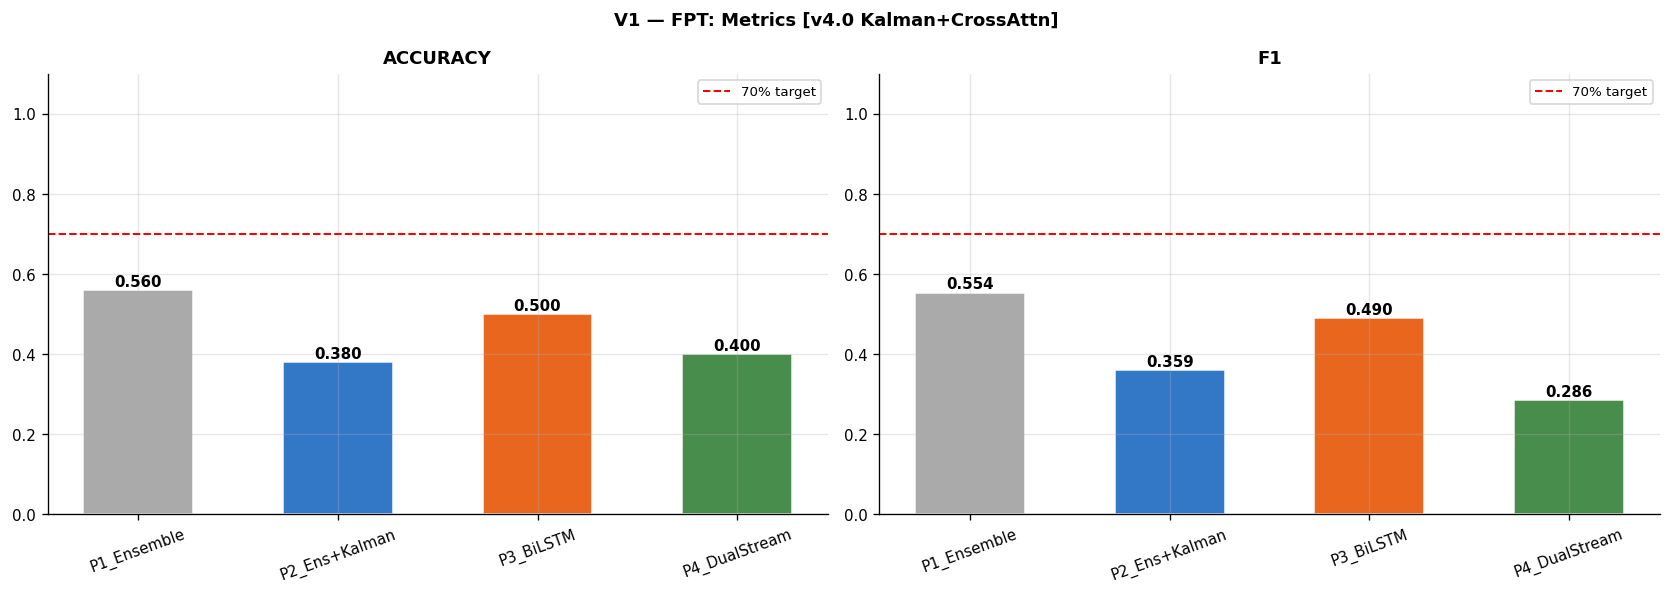

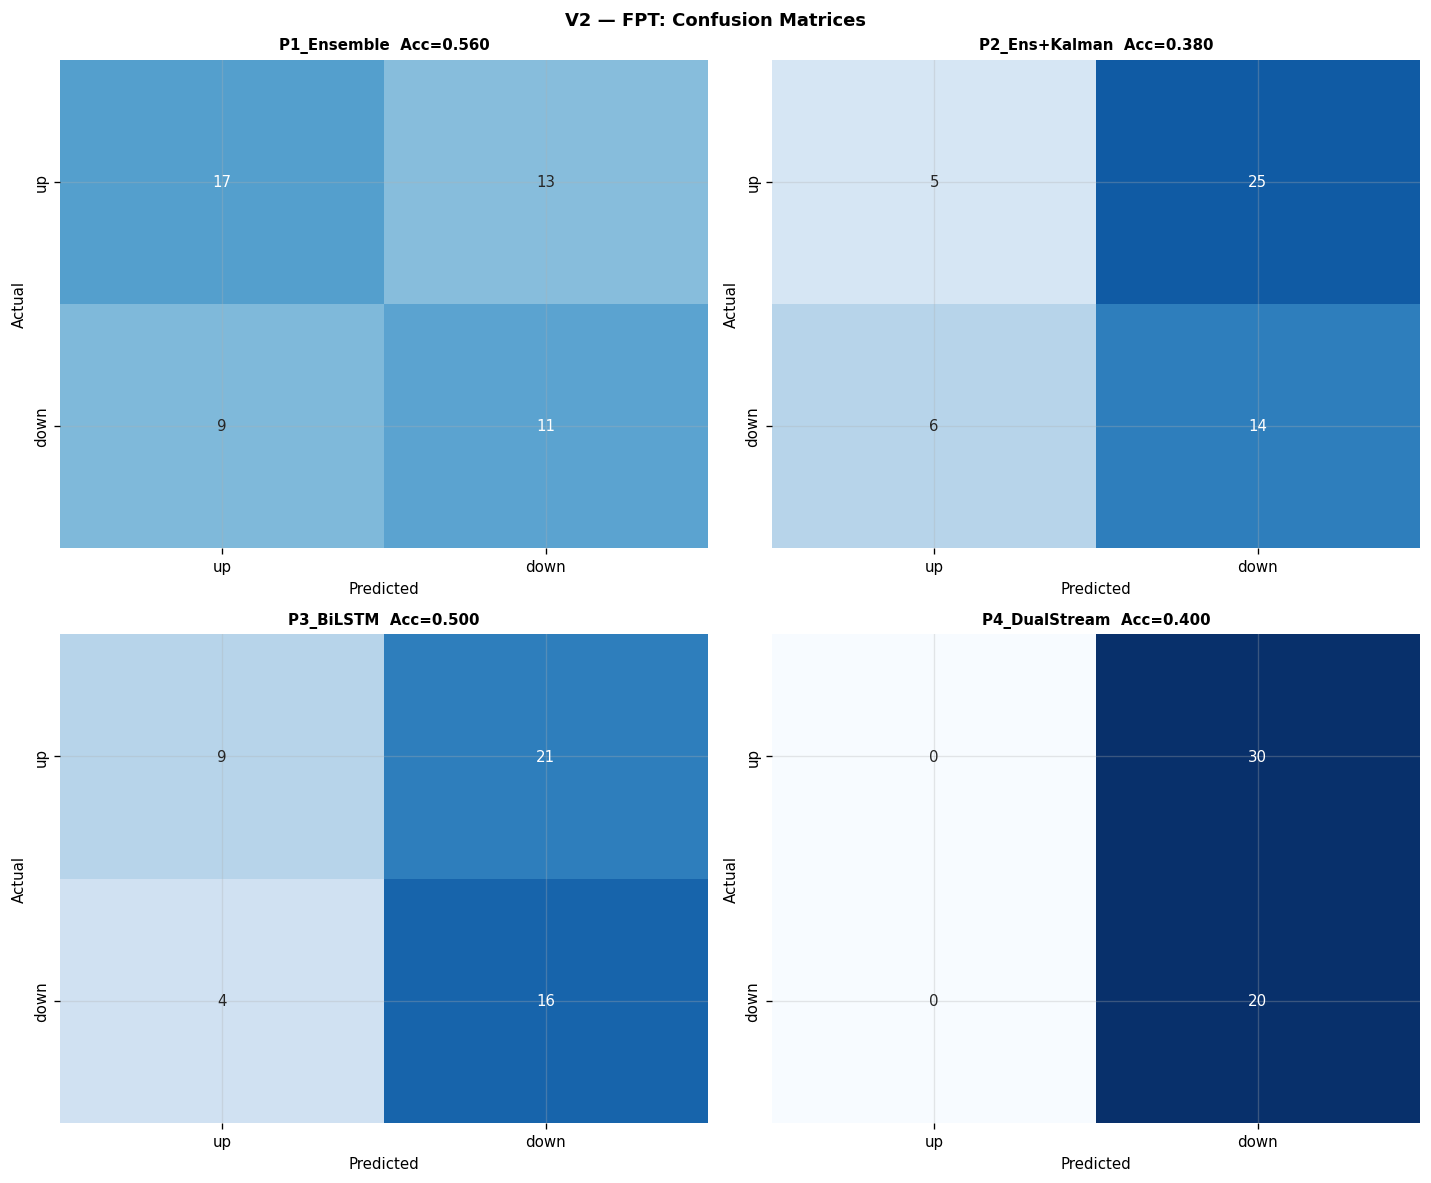

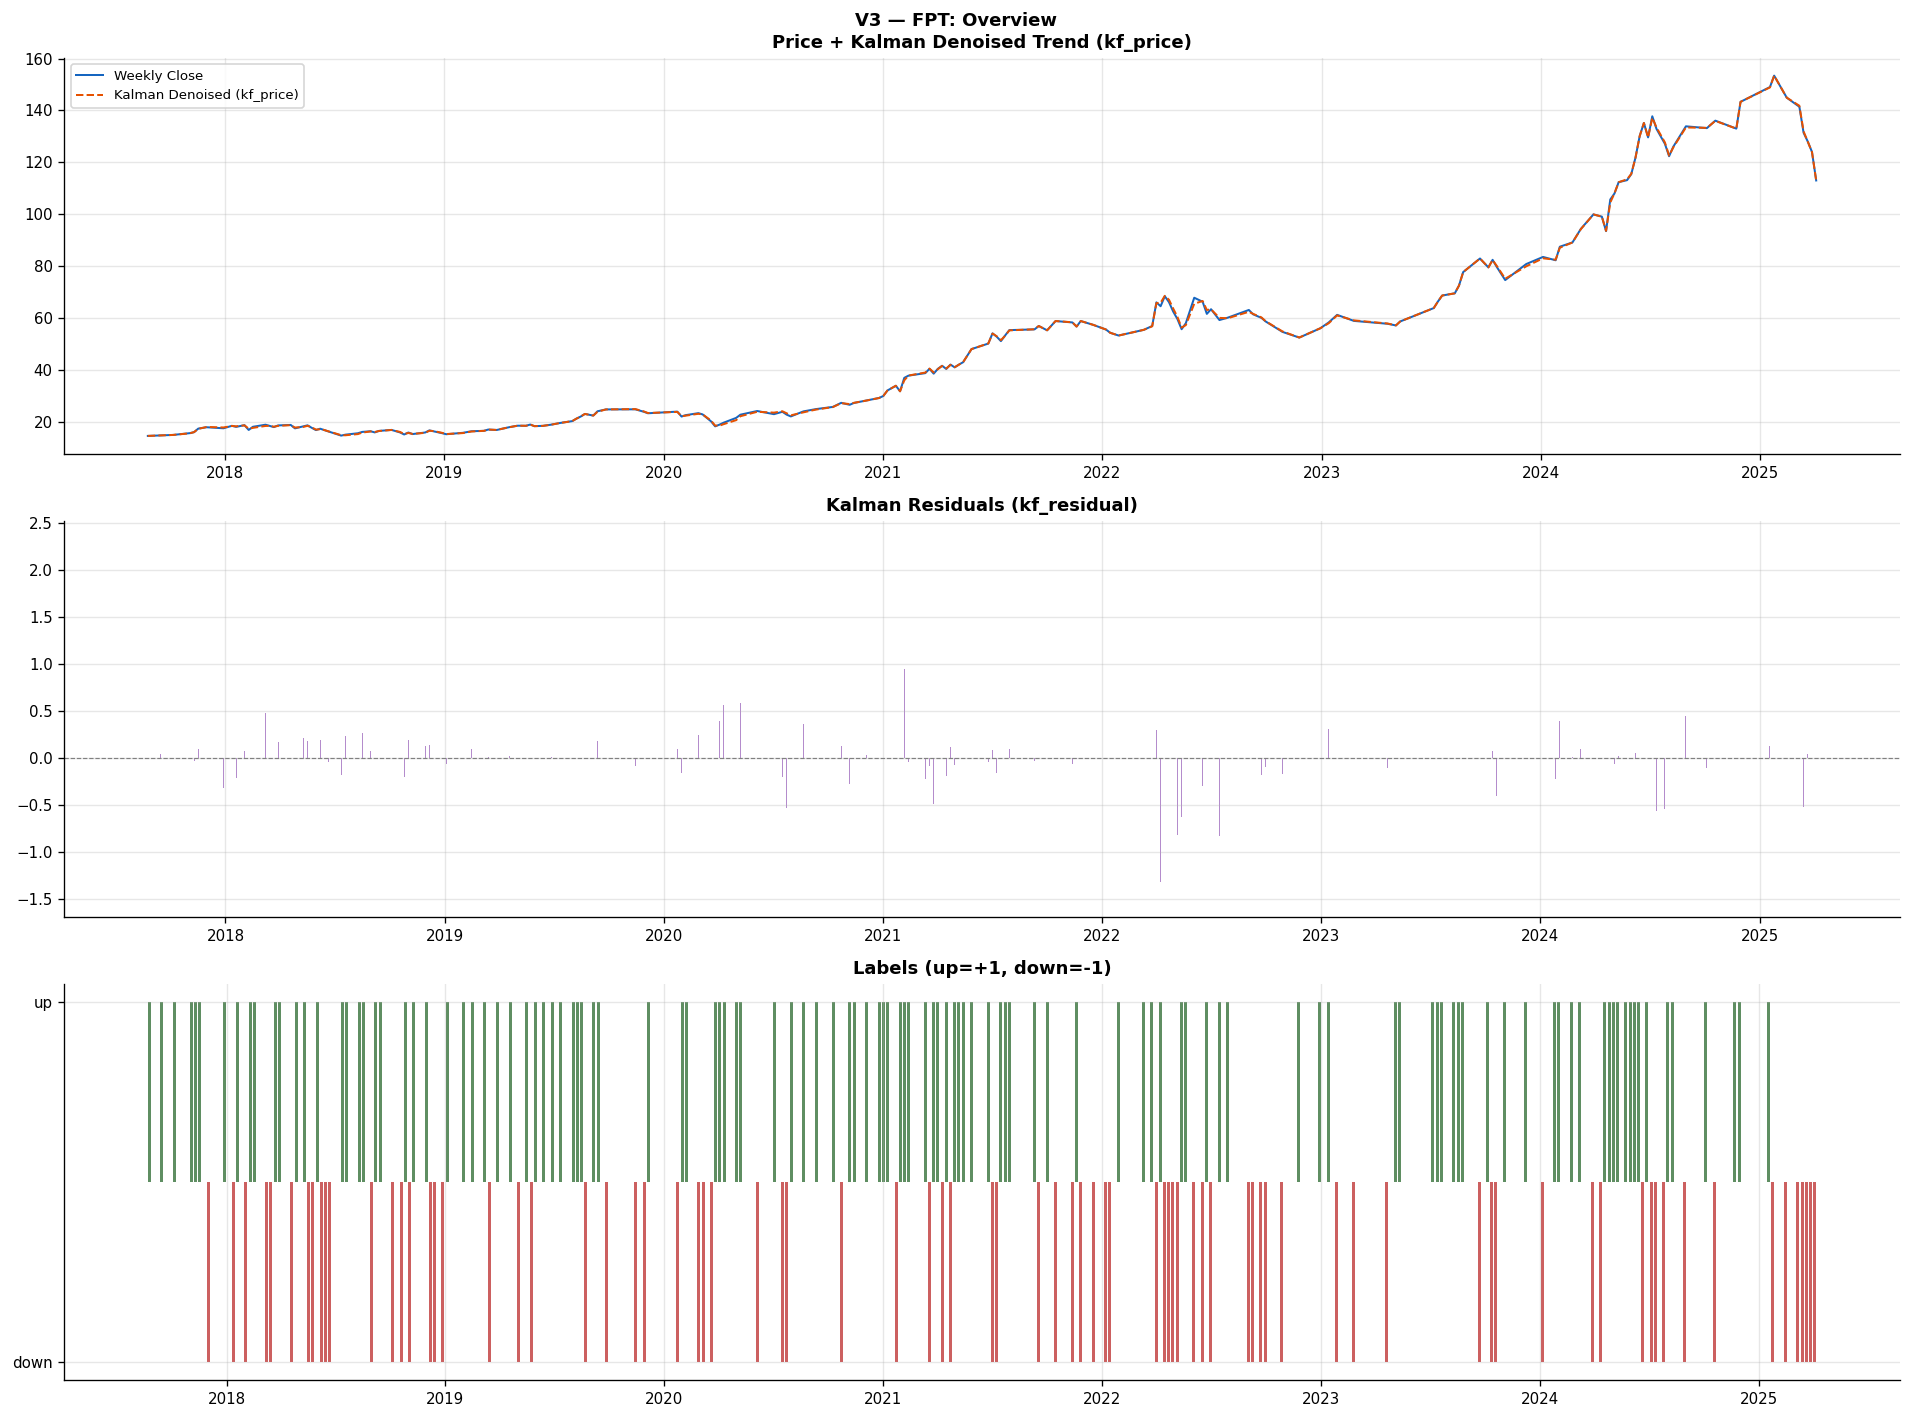

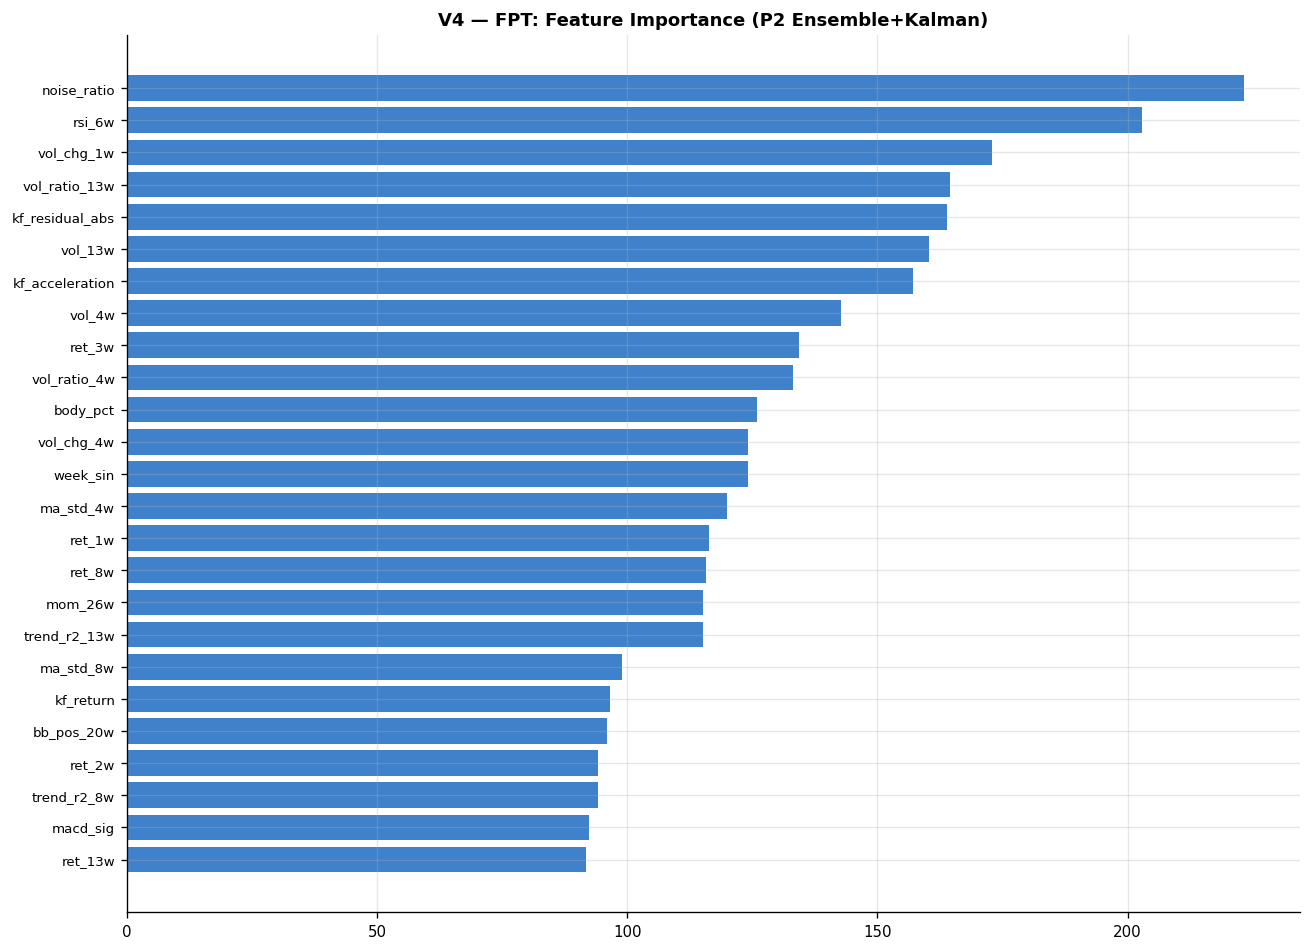

  Plots saved → /kaggle/working/FPT_V*.png

========================================================================  FINAL
        phase  accuracy  precision   recall       f1
  P1_Ensemble      0.56    0.55609 0.558333 0.553571
P2_Ens+Kalman      0.38    0.40676 0.433333 0.359239
    P3_BiLSTM      0.50    0.56237 0.550000 0.490004
P4_DualStream      0.40    0.20000 0.500000 0.285714

  Best acc = 0.5600

Outputs → /kaggle/working/


In [13]:
# =============================================================================
# PART 10 — MAIN PIPELINE
# =============================================================================

_BASE_NAMES: list = []
_KF_NAMES:   list = []


def run_pipeline_from_df(df_daily, stock_name='FPT'):
    global _BASE_NAMES, _KF_NAMES

    print(f"\n{'='*72}")
    print(f"  {stock_name} — v4.0 [Adaptive Kalman + CrossAttn DualStream BiLSTM]")
    print(f"{'='*72}")

    # 1. Resample weekly
    df_d = df_daily.copy()
    df_d['date'] = pd.to_datetime(df_d['date'])
    df_d = df_d.set_index('date').sort_index()
    df_d['volume'] = df_d['volume'] / 1e6
    wk = df_d.resample('W-FRI').agg(
        close=('close','last'), high=('high','max'),
        low=('low','min'), volume=('volume','sum'),
        open=('close','first')).dropna().reset_index()
    wk['mid'] = (wk['high'] + wk['low']) / 2
    print(f"\n[1] Weekly: {len(wk)} weeks  "
          f"{wk['date'].min().date()} → {wk['date'].max().date()}")

    # 2. Label
    print("\n[2] Labeling ...")
    df_labeled = label_weekly(wk, SIGNAL_THR)
    N = len(df_labeled)
    if N < 60:
        print("  ERROR: Too few labeled samples!"); return None

    # 3. Walk-forward config (needed before Kalman to size n_init)
    n_init    = int(N * INIT_FRAC)
    n_remain  = N - n_init
    fold_size = max(MIN_FOLD_SIZE, n_remain // MAX_FOLDS)
    n_folds   = max(1, n_remain // fold_size)
    print(f"\n[3] Walk-forward: N={N} | init={n_init} | "
          f"{n_folds} folds × {fold_size}wk  (min_fold={MIN_FOLD_SIZE})")

    # 4. Adaptive Kalman Filter (walk-forward safe) — runs BEFORE feature eng.
    #    kf_price_all is the full walk-forward denoised series (no future leakage).
    #    It is passed to build_weekly_features and used for plotting.
    print("\n[4] Adaptive Kalman Filter (walk-forward safe) ...")
    close_all = df_labeled['close'].values
    df_kf, kf_price_all, kf_resid_all, kf_obj = build_kalman_features_walkforward(
        close_all, n_init, n_folds, fold_size,
        finetune=KF_FINETUNE, verbose=0)
    _KF_NAMES   = df_kf.columns.tolist()
    d_fit_all   = kf_price_all   # alias for visualize()
    d_resid_all = kf_resid_all   # alias for visualize()

    # 5. Base features built on denoised kf_price (not raw close)
    print("\n[5] Building base features on kf_price ...")
    X_base_df, y_all = build_weekly_features(df_labeled, kf_price=kf_price_all)
    _BASE_NAMES       = X_base_df.columns.tolist()
    X_base_raw        = X_base_df.values.astype(np.float32)
    print(f"  Base features: {len(_BASE_NAMES)}")

    le          = LabelEncoder()
    le.classes_ = np.array(CLASSES)
    y_enc       = le.transform(y_all.values)

    # 6. Scale ONLY for LSTM; keep raw for tree models
    sc_base = StandardScaler().fit(X_base_raw[:n_init])
    X_base_sc = sc_base.transform(X_base_raw).astype(np.float32)

    # All 10 Kalman features (unscaled) — P2 ensemble (LGB/RF handle raw values)
    X_kf_raw = df_kf.values.astype(np.float32)
    print(f"  Kalman feature matrix: {X_kf_raw.shape}  "
          f"cols={df_kf.columns.tolist()}")

    # Stream B: 4 Kalman scalar features (scaled) — P4 LSTM Stream B
    # kf_velocity, kf_acceleration: momentum state
    # kalman_gain, uncertainty_ratio: filter confidence
    sb_cols  = [c for c in KF_STREAM_B_COLS if c in df_kf.columns]
    X_sb_raw = df_kf[sb_cols].values.astype(np.float32)
    sc_sb    = StandardScaler().fit(X_sb_raw[:n_init])
    X_sb_sc  = sc_sb.transform(X_sb_raw).astype(np.float32)
    print(f"  Stream B ({len(sb_cols)} cols): {sb_cols}")

    # ── P1: LGB + RF — base features only ────────────────────────────────────
    print("\n── P1: LGB + RF Ensemble (base features only) ───────────────────")
    y_t1, y_p1, pb1, imp1 = walk_forward(
        X_base_raw, X_base_sc, X_kf_raw, None, X_sb_sc,
        y_enc, CLASSES, le, n_init, n_folds, fold_size, mode='ensemble')
    m1 = evaluate(y_t1, y_p1, 'P1_Ensemble', CLASSES)

    # ── P2: LGB + RF — base + all 10 Kalman features ─────────────────────────
    print("\n── P2: LGB + RF Ensemble (base + 10 Kalman features, unscaled) ─")
    y_t2, y_p2, pb2, imp2 = walk_forward(
        X_base_raw, X_base_sc, X_kf_raw, None, X_sb_sc,
        y_enc, CLASSES, le, n_init, n_folds, fold_size, mode='ensemble_d')
    m2 = evaluate(y_t2, y_p2, 'P2_Ens+Kalman', CLASSES)

    # ── P3: BiLSTM single stream — scaled base features ──────────────────────
    print("\n── P3: BiLSTM single stream (scaled base features) ──────────────")
    y_t3, y_p3, pb3, _ = walk_forward(
        X_base_raw, X_base_sc, X_kf_raw, None, X_sb_sc,
        y_enc, CLASSES, le, n_init, n_folds, fold_size, mode='lstm_single')
    m3 = evaluate(y_t3, y_p3, 'P3_BiLSTM', CLASSES)

    # ── P4: Dual-stream BiLSTM + CrossAttention ───────────────────────────────
    #   Stream A: scaled base features (kf_price-derived indicators)
    #   Stream B: 4 Kalman scalars (kf_velocity, kf_acceleration,
    #             kalman_gain, uncertainty_ratio) — filter confidence context
    print(f"\n── P4: DualStream BiLSTM + CrossAttention (Stream B = {sb_cols}) ─")
    y_t4, y_p4, pb4, _ = walk_forward(
        X_base_raw, X_base_sc, X_kf_raw, None, X_sb_sc,
        y_enc, CLASSES, le, n_init, n_folds, fold_size, mode='lstm_dual')
    m4 = evaluate(y_t4, y_p4, 'P4_DualStream', CLASSES)

    all_results = [m1, m2, m3, m4]
    all_preds   = [list(y_p1), list(y_p2), list(y_p3), list(y_p4)]
    y_true_ref  = list(y_t1)

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\n{'='*72}")
    print(f"  SUMMARY — {stock_name}  [{n_folds}×{fold_size}wk | "
          f"signal>{SIGNAL_THR}%]")
    print(f"{'='*72}")
    df_sum = pd.DataFrame(all_results)
    print(df_sum[['phase','accuracy','precision','recall','f1']].to_string(index=False))
    df_sum.to_csv(f'{OUT_DIR}/{stock_name}_summary.csv', index=False)

    best = df_sum.loc[df_sum['accuracy'].idxmax()]
    print(f"\n  Best: {best['phase']}  acc={best['accuracy']:.4f}  "
          f"{'ACHIEVED >=70%' if best['accuracy'] >= 0.70 else '<70%'}")
    print(f"  dAcc P2-P1 = {m2['accuracy']-m1['accuracy']:+.4f}  [Kalman → Ensemble]")
    print(f"  dAcc P3-P1 = {m3['accuracy']-m1['accuracy']:+.4f}  [BiLSTM vs Ensemble]")
    print(f"  dAcc P4-P3 = {m4['accuracy']-m3['accuracy']:+.4f}  [CrossAttn vs single]")

    visualize(stock_name, all_results, CLASSES, df_labeled,
              all_preds, y_true_ref, d_fit_all, d_resid_all, imp_df=imp2)

    return dict(results=all_results, y_true=y_true_ref,
                preds=dict(P1=list(y_p1), P2=list(y_p2),
                           P3=list(y_p3), P4=list(y_p4)),
                df_labeled=df_labeled, importance=imp2,
                kf_filter=kf_obj, d_fit=d_fit_all, d_resid=d_resid_all)


# =============================================================================
# ENTRY POINT
# =============================================================================

print("\nLoading FPT data ...")
df_fpt = load_daily(DATA_PATH_FPT, 'High_FPT', 'Low_FPT',
                    'Volume_FPT', 'Close_FPT')
print(f"FPT: {len(df_fpt)} rows  "
      f"({df_fpt['date'].min().date()} → {df_fpt['date'].max().date()})")

fpt_results = run_pipeline_from_df(df_fpt, stock_name='FPT')

# df_cmc = load_daily(DATA_PATH_CMC, 'High_CMC','Low_CMC','Volume_CMC','Close_CMC')
# cmc_results = run_pipeline_from_df(df_cmc, stock_name='CMC')

print(f"\n{'='*72}  FINAL")
if fpt_results:
    df_s = pd.DataFrame(fpt_results['results'])
    print(df_s[['phase','accuracy','precision','recall','f1']].to_string(index=False))
    print(f"\n  Best acc = {df_s['accuracy'].max():.4f}")
print(f"\nOutputs → {OUT_DIR}/")
print("=" * 72)